## 프로젝트: SentencePiece 사용하기

In [1]:
# !pip install konlpy

In [2]:
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.6.0


In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence

import pandas as pd
from collections import Counter
import os, re

In [4]:
# 재현성을 위한 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


### SentencePiece 설치

In [5]:
# !pip install sentencepiece

### SentencePiece 모델 학습

#### 코퍼스 분석 및 전처리

In [6]:
# # 코퍼스 다운로드
# !wget -q https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
# !tar -xzf korean-english-park.train.tar.gz

In [7]:
# 코퍼스 분석
path_to_file = 'korean-english-park.train.ko'

with open(path_to_file, 'r') as f:
    raw = f.read().splitlines()

print('전체 데이터 크기:', len(raw))
print('\n샘플 문장:')
for sen in raw[0:100][::20]:
    print('>>', sen)

전체 데이터 크기: 94123

샘플 문장:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


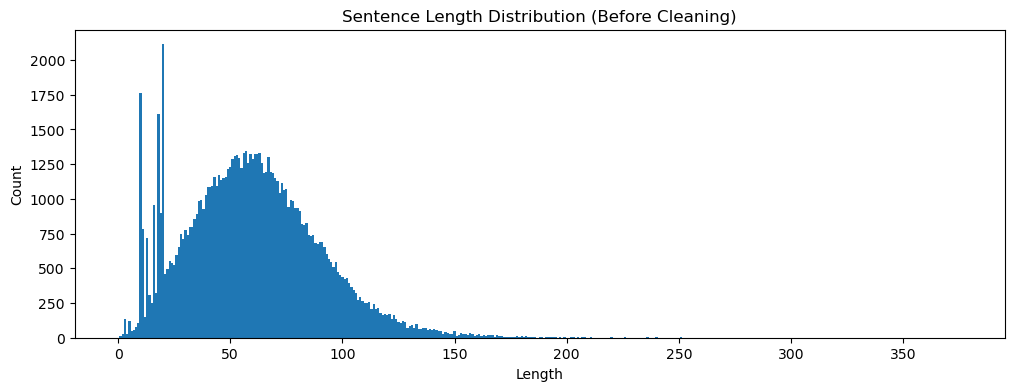

In [8]:
# 문장 길이 분포 분석
min_len = min(len(s) for s in raw)
max_len = max(len(s) for s in raw)
avg_len = sum(len(s) for s in raw) // len(raw)

print(f'문장의 최단 길이: {min_len}')
print(f'문장의 최장 길이: {max_len}')
print(f'문장의 평균 길이: {avg_len}')

sentence_length = np.zeros(max_len, dtype=int)
for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.figure(figsize=(12, 4))
plt.bar(range(max_len), sentence_length, width=1.0)
plt.title('Sentence Length Distribution (Before Cleaning)')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

중복 제거 후: 77591건 (원본: 94123건)
길이 필터링 후: 76908건


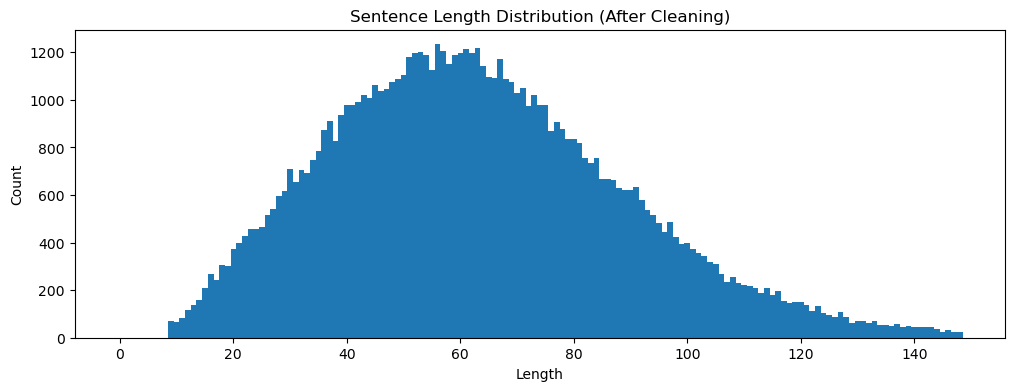

In [9]:
# 전처리: 중복 제거 + 길이 필터링

# 1) 중복 제거
cleaned_corpus = list(set(raw))
print(f'중복 제거 후: {len(cleaned_corpus)}건 (원본: {len(raw)}건)')

# 2) 너무 짧거나 긴 문장 제거 (10 <= 길이 < 150)
filtered_corpus = [s for s in cleaned_corpus if 10 <= len(s) < 150]
print(f'길이 필터링 후: {len(filtered_corpus)}건')

# 최종 분포 확인
max_len_f = max(len(s) for s in filtered_corpus)
sentence_length_f = np.zeros(max_len_f, dtype=int)
for sen in filtered_corpus:
    sentence_length_f[len(sen)-1] += 1

plt.figure(figsize=(12, 4))
plt.bar(range(max_len_f), sentence_length_f, width=1.0)
plt.title('Sentence Length Distribution (After Cleaning)')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

#### SentencePiece 적용

In [10]:
import sentencepiece as spm

# 학습용 텍스트 파일 생성
temp_file = 'korean-english-park.train.ko.temp'

with open(temp_file, 'w') as f:
    for row in filtered_corpus:
        f.write(str(row) + '\n')

# --- SentencePiece 모델 학습 (Unigram, vocab_size=8000) ---
vocab_size = 8000

spm.SentencePieceTrainer.Train(
    f'--input={temp_file} '
    f'--model_prefix=korean_spm '
    f'--vocab_size={vocab_size} '
    f'--model_type=unigram '
    f'--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
)

print('학습 완료!')
!ls -l korean_spm*

학습 완료!
-rw-rw-r-- 1 jovyan users 379835 Apr 13 18:44 korean_spm.model
-rw-rw-r-- 1 jovyan users 146741 Apr 13 18:44 korean_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean-english-park.train.ko.temp --model_prefix=korean_spm --vocab_size=8000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean-english-park.train.ko.temp
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepiece

In [11]:
# 토크나이저 동작 확인
sp = spm.SentencePieceProcessor()
sp.Load('korean_spm.model')

test_sentences = [
    '아버지가방에들어가신다.',
    '자연어처리는 정말 재미있는 분야입니다.',
    '코로나바이러스는 2019년 중국 우한에서 처음 발생했다.'
]

for sent in test_sentences:
    print(f'원문: {sent}')
    print(f'  Pieces : {sp.EncodeAsPieces(sent)}')
    print(f'  IDs    : {sp.EncodeAsIds(sent)}')
    print(f'  복원   : {sp.DecodeIds(sp.EncodeAsIds(sent))}')
    print()

원문: 아버지가방에들어가신다.
  Pieces : ['▁아버지', '가', '방', '에', '들어', '가', '신', '다', '.']
  IDs    : [1247, 12, 303, 8, 3542, 12, 288, 34, 5]
  복원   : 아버지가방에들어가신다.

원문: 자연어처리는 정말 재미있는 분야입니다.
  Pieces : ['▁자연', '어', '처', '리는', '▁정말', '▁재미있', '는', '▁분야', '입니다', '.']
  IDs    : [2606, 70, 831, 961, 2885, 6604, 11, 2259, 533, 5]
  복원   : 자연어처리는 정말 재미있는 분야입니다.

원문: 코로나바이러스는 2019년 중국 우한에서 처음 발생했다.
  Pieces : ['▁코', '로', '나', '바', '이', '러스', '는', '▁20', '19', '년', '▁중국', '▁우', '한', '에서', '▁처음', '▁발생했다', '.']
  IDs    : [534, 17, 72, 175, 9, 4235, 11, 275, 2765, 38, 118, 556, 18, 16, 855, 1111, 5]
  복원   : 코로나바이러스는 2019년 중국 우한에서 처음 발생했다.



### Tokenizer 함수 작성

In [12]:
def sp_tokenize(sp_model, corpus):
    '''
    SentencePiece 모델을 사용한 토크나이저 함수
    
    Args:
        sp_model: 로드된 SentencePieceProcessor 객체
        corpus: 문장 리스트 (list of str)
    
    Returns:
        tensor: 패딩된 인코딩 텐서
        word_index: {word: idx} 사전
        index_word: {idx: word} 사전
    '''
    # 1) 각 문장을 SentencePiece로 인코딩
    encoded = []
    for sen in corpus:
        encoded.append(torch.tensor(sp_model.EncodeAsIds(sen), dtype=torch.long))
    
    # 2) vocab 파일에서 word_index / index_word 사전 생성
    word_index = {}
    index_word = {}
    vocab_size = sp_model.GetPieceSize()
    
    for idx in range(vocab_size):
        word = sp_model.IdToPiece(idx)
        word_index[word] = idx
        index_word[idx] = word
    
    # 3) 패딩 (pad_id=0)
    tensor = pad_sequence(encoded, batch_first=True, padding_value=0)
    
    return tensor, word_index, index_word

In [13]:
# sp_tokenize 함수 동작 확인
sp_tensor, sp_word_index, sp_index_word = sp_tokenize(sp, filtered_corpus)

print(f'SentencePiece Vocab Size: {len(sp_word_index)}')
print(f'Tensor shape: {sp_tensor.shape}')

# 디코딩 테스트
sample_idx = 100
sample_ids = sp_tensor[sample_idx].tolist()
sample_ids = [i for i in sample_ids if i != 0]  # 패딩 제거
print(f'\n인코딩: {sample_ids[:20]}...')
print(f'디코딩: {sp.DecodeIds(sample_ids)}')

SentencePiece Vocab Size: 8000
Tensor shape: torch.Size([76908, 100])

인코딩: [2607, 744, 332, 1309, 3279, 629, 673, 10, 5180, 165, 3200, 5684, 7, 5788, 73, 4425, 8, 5788, 10, 450]...
디코딩: 수백 명의 지원자들이 홍수로부터 도시를 보호하기 위한 150만개의 모래주머니에 모래를 채우고 있습니다.


In [14]:
# # MeCab 설치
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
# %cd Mecab-ko-for-Google-Colab/
# !bash install_mecab-ko_on_colab_light_220429.sh
# %cd ..

In [15]:
from konlpy.tag import Mecab
mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


In [16]:
# 공백 / Mecab / SentencePiece 단어 사전 크기 비교

# 공백 기반 토큰화 단어 사전 크기
split_vocab = set()
for sen in filtered_corpus:
    for w in sen.split():
        split_vocab.add(w)
print(f'공백 기반 Vocab Size     : {len(split_vocab)}')

# MeCab 기반 토큰화 단어 사전 크기
mecab_vocab = set()
for sen in filtered_corpus:
    for w in mecab.morphs(sen):
        mecab_vocab.add(w)
print(f'MeCab 기반 Vocab Size    : {len(mecab_vocab)}')

# SentencePiece Vocab Size
print(f'SentencePiece Vocab Size : {len(sp_word_index)}')

공백 기반 Vocab Size     : 238305
MeCab 기반 Vocab Size    : 53642
SentencePiece Vocab Size : 8000


SentencePiece는 vocab size를 지정해서 학습할 수 있어 메모리가 효율적이다

### 네이버 영화리뷰 감정 분석 문제에 SentencePiece 적용해보기

In [17]:
# # NSMC 데이터셋 다운로드
# !wget -q https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
# !wget -q https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
# print('NSMC 다운로드 완료!')

In [18]:
# 데이터 읽기 및 기본 전처리
train_data = pd.read_table('ratings_train.txt')
test_data = pd.read_table('ratings_test.txt')

print(f'훈련 데이터: {train_data.shape}')
print(f'테스트 데이터: {test_data.shape}')

# 중복 제거 & 결측치 제거
train_data = train_data.drop_duplicates(subset=['document']).dropna(how='any')
test_data = test_data.drop_duplicates(subset=['document']).dropna(how='any')

print(f'\n전처리 후 훈련 데이터: {len(train_data)}건')
print(f'전처리 후 테스트 데이터: {len(test_data)}건')
print(f'\n라벨 분포:\n{train_data["label"].value_counts()}')

훈련 데이터: (150000, 3)
테스트 데이터: (50000, 3)

전처리 후 훈련 데이터: 146182건
전처리 후 테스트 데이터: 49157건

라벨 분포:
label
0    73342
1    72840
Name: count, dtype: int64


#### NSMC 전용 SentencePiece 모델 학습

In [19]:
# NSMC 훈련 데이터로 SentencePiece 모델 학습
nsmc_temp_file = 'nsmc_train_text.txt'

with open(nsmc_temp_file, 'w') as f:
    for doc in train_data['document']:
        f.write(str(doc) + '\n')

# Unigram 모델, vocab_size=8000
spm.SentencePieceTrainer.Train(
    f'--input={nsmc_temp_file} '
    f'--model_prefix=nsmc_spm_unigram_8k '
    f'--vocab_size=8000 '
    f'--model_type=unigram '
    f'--pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1 '
    f'--user_defined_symbols=<UNK>'
)
print('NSMC SentencePiece 모델 학습 완료 (unigram, 8k)')

NSMC SentencePiece 모델 학습 완료 (unigram, 8k)


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_train_text.txt --model_prefix=nsmc_spm_unigram_8k --vocab_size=8000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1 --user_defined_symbols=<UNK>
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_train_text.txt
  input_format: 
  model_prefix: nsmc_spm_unigram_8k
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <UNK>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  t

In [20]:
# 공통 유틸리티 함수 정의
# ============================================================
# 패딩 함수
# ============================================================
def pad_sequences_fn(data, maxlen, padding='pre'):
    """
    문장을 maxlen 길이로 맞춰주는 패딩 함수.
    padding='pre': 앞쪽에 0을 채움 (RNN에 유리)
    """
    padded = []
    for seq in data:
        if len(seq) >= maxlen:
            padded.append(seq[:maxlen])
        else:
            pad_len = maxlen - len(seq)
            if padding == 'pre':
                padded.append([0] * pad_len + seq)
            else:
                padded.append(seq + [0] * pad_len)
    return np.array(padded)


# ============================================================
# LSTM 모델
# ============================================================
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=32):  # 64→32
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim,
                           batch_first=True, num_layers=1)  # 2→1, dropout 제거
        self.dropout = nn.Dropout(0.3)  # 0.5→0.3
        self.fc = nn.Linear(hidden_dim, 1)  # fc 2개→1개로 단순화

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]
        x = self.dropout(x)
        x = torch.sigmoid(self.fc(x))  # relu+fc1+fc2 → fc 하나로
        return x


# ============================================================
# 학습 / 평가 / 시각화 함수
# ============================================================
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, patience=3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_acc = 0.0          # early stopping을 위한 변수 초기
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(correct / total)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_correct / val_total)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f}, Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f}, Acc: {history['val_acc'][-1]:.4f}")
        if history['val_acc'][-1] > best_val_acc: # early stopping추가
            best_val_acc = history['val_acc'][-1]
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly Stopping! Best Val Acc: {best_val_acc:.4f}')
                model.load_state_dict(best_model_state)
                break
    return history


def evaluate_model(model, test_loader):
    model.eval()
    loss_fn = nn.BCELoss()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)
            test_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {acc:.4f}")
    return acc


def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs_range, history['train_loss'], 'bo-', label='Train Loss')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(epochs_range, history['train_acc'], 'bo-', label='Train Acc')
    axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

#### 다른 토크나이저와 비교

In [21]:
# ============================================================
# MeCab 기반 전처리 파이프라인
# ============================================================
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘',
             '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

def load_data_mecab(train_df, test_df, num_words=10000):
    """MeCab 형태소 분석기를 사용한 NSMC 전처리"""
    # 토큰화 + 불용어 제거
    X_train = []
    for sentence in train_df['document']:
        tokens = mecab.morphs(str(sentence))
        tokens = [w for w in tokens if w not in stopwords]
        X_train.append(tokens)

    X_test = []
    for sentence in test_df['document']:
        tokens = mecab.morphs(str(sentence))
        tokens = [w for w in tokens if w not in stopwords]
        X_test.append(tokens)

    # 단어 사전 구성 (빈도 기반 상위 num_words개)
    words = [w for sent in X_train for w in sent]
    counter = Counter(words).most_common(num_words - 4)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [k for k, _ in counter]
    word_to_index = {word: idx for idx, word in enumerate(vocab)}

    def to_indices(wordlist):
        return [word_to_index.get(w, word_to_index['<UNK>']) for w in wordlist]

    X_train = list(map(to_indices, X_train))
    X_test = list(map(to_indices, X_test))

    return (X_train, np.array(list(train_df['label'])),
            X_test, np.array(list(test_df['label'])), word_to_index)


# ============================================================
# SentencePiece 기반 전처리 파이프라인
# ============================================================
def load_data_sp(train_df, test_df, sp_model):
    """SentencePiece를 사용한 NSMC 전처리"""
    X_train = [sp_model.EncodeAsIds(str(s)) for s in train_df['document']]
    X_test = [sp_model.EncodeAsIds(str(s)) for s in test_df['document']]

    vocab_size = sp_model.GetPieceSize()
    word_to_index = {sp_model.IdToPiece(i): i for i in range(vocab_size)}

    return (X_train, np.array(list(train_df['label'])),
            X_test, np.array(list(test_df['label'])), word_to_index)

In [22]:
def build_loaders(X_train, y_train, X_test, y_test, maxlen=40, batch_size=256):
    """
    토큰화된 데이터를 패딩하고 DataLoader로 변환하는 공통 함수.
    Returns: train_loader, val_loader, test_loader
    """
    # 패딩
    X_train_pad = pad_sequences_fn(X_train, maxlen, padding='pre')
    X_test_pad = pad_sequences_fn(X_test, maxlen, padding='pre')

    # Validation 분리 (20%)
    val_size = int(len(X_train_pad) * 0.2)

    X_val = torch.tensor(X_train_pad[:val_size], dtype=torch.long)
    X_train_t = torch.tensor(X_train_pad[val_size:], dtype=torch.long)
    y_val = torch.tensor(y_train[:val_size], dtype=torch.float32)
    y_train_t = torch.tensor(y_train[val_size:], dtype=torch.float32)

    X_test_t = torch.tensor(X_test_pad, dtype=torch.long)
    y_test_t = torch.tensor(y_test, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val),
                            batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                             batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

1. Mecab 기반 모델

In [23]:
# MeCab 기반 데이터 준비
print('=== MeCab 토크나이저 기반 전처리 ===')
X_train_m, y_train_m, X_test_m, y_test_m, word_index_m = load_data_mecab(train_data, test_data)

# 문장 길이 분석하여 maxlen 결정
all_lengths = [len(s) for s in X_train_m + X_test_m]
maxlen = int(np.mean(all_lengths) + 2 * np.std(all_lengths))
print(f'평균 토큰 수: {np.mean(all_lengths):.1f}, maxlen: {maxlen}')
print(f'Vocab Size: {len(word_index_m)}')

=== MeCab 토크나이저 기반 전처리 ===
평균 토큰 수: 16.0, maxlen: 41
Vocab Size: 10000


In [24]:
# MeCab 모델 학습
embedding_dim = 64  # 128→64
batch_size = 256

train_loader_m, val_loader_m, test_loader_m = build_loaders(
    X_train_m, y_train_m, X_test_m, y_test_m, maxlen=maxlen, batch_size=batch_size)

model_mecab = LSTMModel(len(word_index_m), embedding_dim)
print(model_mecab)
print(f'\n학습 시작 (MeCab + LSTM)...')
history_mecab = train_model(model_mecab, train_loader_m, val_loader_m, epochs=10)

LSTMModel(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 32, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

학습 시작 (MeCab + LSTM)...
Epoch  1/10 | Train Loss: 0.5261, Acc: 0.7277 | Val Loss: 0.4113, Acc: 0.8139
Epoch  2/10 | Train Loss: 0.3861, Acc: 0.8281 | Val Loss: 0.3711, Acc: 0.8346
Epoch  3/10 | Train Loss: 0.3521, Acc: 0.8469 | Val Loss: 0.3638, Acc: 0.8413
Epoch  4/10 | Train Loss: 0.3236, Acc: 0.8632 | Val Loss: 0.3524, Acc: 0.8462
Epoch  5/10 | Train Loss: 0.3017, Acc: 0.8750 | Val Loss: 0.3520, Acc: 0.8487
Epoch  6/10 | Train Loss: 0.2857, Acc: 0.8822 | Val Loss: 0.3507, Acc: 0.8512
Epoch  7/10 | Train Loss: 0.2714, Acc: 0.8896 | Val Loss: 0.3571, Acc: 0.8518
Epoch  8/10 | Train Loss: 0.2580, Acc: 0.8957 | Val Loss: 0.3531, Acc: 0.8532
Epoch  9/10 | Train Loss: 0.2458, Acc: 0.9018 | Val Loss: 0.3663, Acc: 0.8519
Epoch 10/10 | Train Loss: 0.2344, Acc: 0.9076 | Val Loss: 0.3740, A

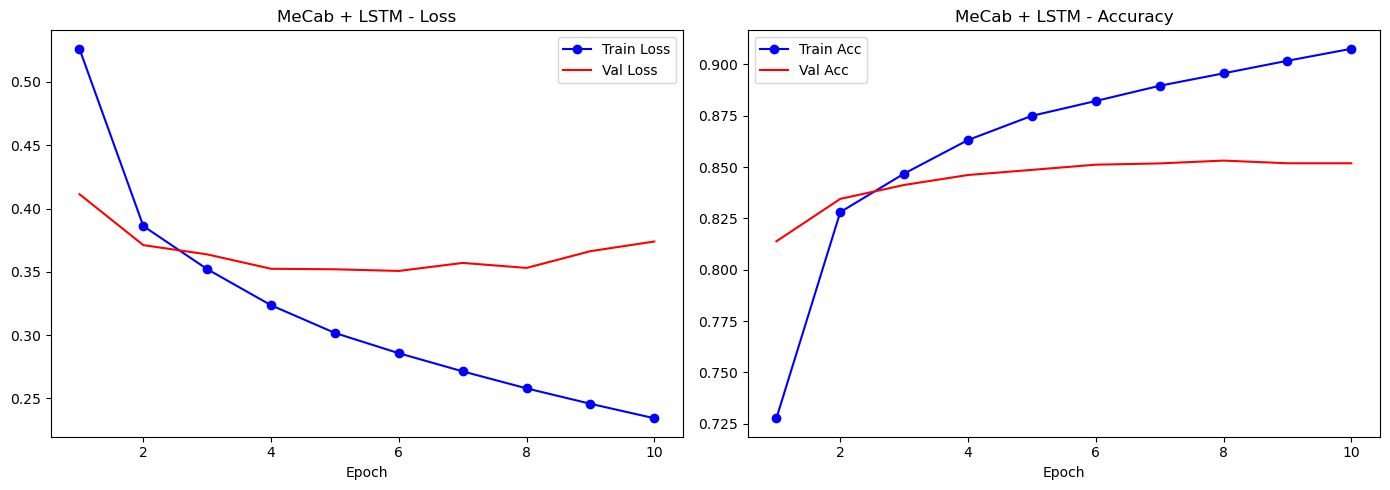


=== MeCab 모델 테스트 결과 ===
Test Loss: 0.3793, Test Accuracy: 0.8483


In [25]:
plot_history(history_mecab, title='MeCab + LSTM')
print('\n=== MeCab 모델 테스트 결과 ===')
acc_mecab = evaluate_model(model_mecab, test_loader_m)

2. SentencePiece (Unigram, vocab_size=8000) 기반 모델

In [26]:
# SentencePiece 모델 로드
sp_nsmc = spm.SentencePieceProcessor()
sp_nsmc.Load('nsmc_spm_unigram_8k.model')

print('=== SentencePiece (Unigram, 8k) 기반 전처리 ===')
X_train_sp, y_train_sp, X_test_sp, y_test_sp, word_index_sp = load_data_sp(
    train_data, test_data, sp_nsmc)

# 문장 길이 분석
all_lengths_sp = [len(s) for s in X_train_sp + X_test_sp]
maxlen_sp = int(np.mean(all_lengths_sp) + 2 * np.std(all_lengths_sp))
print(f'평균 토큰 수: {np.mean(all_lengths_sp):.1f}, maxlen: {maxlen_sp}')
print(f'Vocab Size: {len(word_index_sp)}')

=== SentencePiece (Unigram, 8k) 기반 전처리 ===
평균 토큰 수: 17.4, maxlen: 47
Vocab Size: 8000


In [27]:
# SentencePiece (Unigram 8k) 모델 학습
train_loader_sp, val_loader_sp, test_loader_sp = build_loaders(
    X_train_sp, y_train_sp, X_test_sp, y_test_sp, maxlen=maxlen_sp, batch_size=batch_size)

model_sp_uni8k = LSTMModel(len(word_index_sp), embedding_dim)
print(f'\n학습 시작 (SentencePiece Unigram 8k + LSTM)...')
history_sp_uni8k = train_model(model_sp_uni8k, train_loader_sp, val_loader_sp, epochs=10)


학습 시작 (SentencePiece Unigram 8k + LSTM)...
Epoch  1/10 | Train Loss: 0.5974, Acc: 0.6686 | Val Loss: 0.4806, Acc: 0.7739
Epoch  2/10 | Train Loss: 0.4323, Acc: 0.8043 | Val Loss: 0.4059, Acc: 0.8157
Epoch  3/10 | Train Loss: 0.3676, Acc: 0.8400 | Val Loss: 0.3704, Acc: 0.8375
Epoch  4/10 | Train Loss: 0.3327, Acc: 0.8567 | Val Loss: 0.3596, Acc: 0.8424
Epoch  5/10 | Train Loss: 0.3093, Acc: 0.8685 | Val Loss: 0.3536, Acc: 0.8472
Epoch  6/10 | Train Loss: 0.2916, Acc: 0.8780 | Val Loss: 0.3562, Acc: 0.8471
Epoch  7/10 | Train Loss: 0.2773, Acc: 0.8839 | Val Loss: 0.3606, Acc: 0.8477
Epoch  8/10 | Train Loss: 0.2628, Acc: 0.8911 | Val Loss: 0.3634, Acc: 0.8466
Epoch  9/10 | Train Loss: 0.2494, Acc: 0.8972 | Val Loss: 0.3798, Acc: 0.8480
Epoch 10/10 | Train Loss: 0.2372, Acc: 0.9046 | Val Loss: 0.3734, Acc: 0.8481


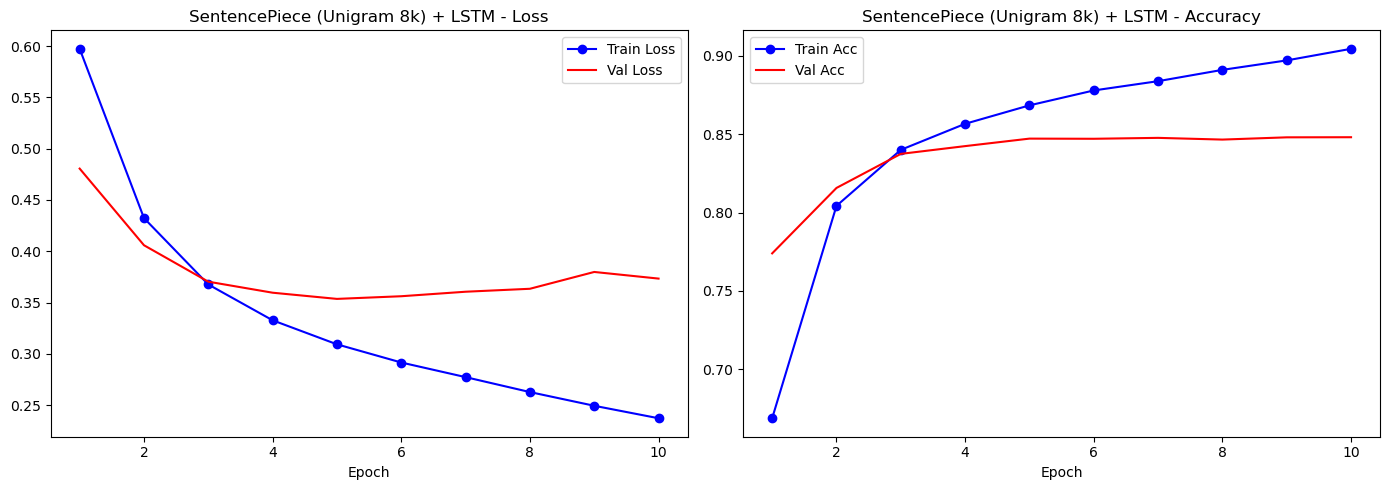


=== SentencePiece (Unigram 8k) 모델 테스트 결과 ===
Test Loss: 0.3876, Test Accuracy: 0.8425


In [28]:
plot_history(history_sp_uni8k, title='SentencePiece (Unigram 8k) + LSTM')
print('\n=== SentencePiece (Unigram 8k) 모델 테스트 결과 ===')
acc_sp_uni8k = evaluate_model(model_sp_uni8k, test_loader_sp)

3. SentencePiece (BPE, vocab_size=8000)

In [29]:
# BPE 모델 학습
spm.SentencePieceTrainer.Train(
    f'--input={nsmc_temp_file} '
    f'--model_prefix=nsmc_spm_bpe_8k '
    f'--vocab_size=8000 '
    f'--model_type=bpe '
    f'--pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1'
)
print('BPE 8k 모델 학습 완료')

sp_bpe8k = spm.SentencePieceProcessor()
sp_bpe8k.Load('nsmc_spm_bpe_8k.model')

X_train_bpe, y_train_bpe, X_test_bpe, y_test_bpe, wi_bpe = load_data_sp(
    train_data, test_data, sp_bpe8k)

all_len_bpe = [len(s) for s in X_train_bpe + X_test_bpe]
maxlen_bpe = int(np.mean(all_len_bpe) + 2 * np.std(all_len_bpe))
print(f'평균 토큰 수: {np.mean(all_len_bpe):.1f}, maxlen: {maxlen_bpe}')

BPE 8k 모델 학습 완료


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_train_text.txt --model_prefix=nsmc_spm_bpe_8k --vocab_size=8000 --model_type=bpe --pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_train_text.txt
  input_format: 
  model_prefix: nsmc_spm_bpe_8k
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_li

평균 토큰 수: 17.0, maxlen: 45


In [30]:
train_loader_bpe, val_loader_bpe, test_loader_bpe = build_loaders(
    X_train_bpe, y_train_bpe, X_test_bpe, y_test_bpe, maxlen=maxlen_bpe, batch_size=batch_size)

model_sp_bpe8k = LSTMModel(len(wi_bpe), embedding_dim)
print('학습 시작 (SentencePiece BPE 8k + LSTM)...')
history_sp_bpe8k = train_model(model_sp_bpe8k, train_loader_bpe, val_loader_bpe, epochs=10)

학습 시작 (SentencePiece BPE 8k + LSTM)...
Epoch  1/10 | Train Loss: 0.5809, Acc: 0.6817 | Val Loss: 0.4599, Acc: 0.7866
Epoch  2/10 | Train Loss: 0.4125, Acc: 0.8158 | Val Loss: 0.3864, Acc: 0.8283
Epoch  3/10 | Train Loss: 0.3619, Acc: 0.8429 | Val Loss: 0.3647, Acc: 0.8408
Epoch  4/10 | Train Loss: 0.3265, Acc: 0.8613 | Val Loss: 0.3563, Acc: 0.8446
Epoch  5/10 | Train Loss: 0.3070, Acc: 0.8706 | Val Loss: 0.3543, Acc: 0.8467
Epoch  6/10 | Train Loss: 0.2898, Acc: 0.8790 | Val Loss: 0.3508, Acc: 0.8477
Epoch  7/10 | Train Loss: 0.2753, Acc: 0.8860 | Val Loss: 0.3546, Acc: 0.8482
Epoch  8/10 | Train Loss: 0.2620, Acc: 0.8924 | Val Loss: 0.3619, Acc: 0.8472
Epoch  9/10 | Train Loss: 0.2501, Acc: 0.8980 | Val Loss: 0.3643, Acc: 0.8482
Epoch 10/10 | Train Loss: 0.2370, Acc: 0.9045 | Val Loss: 0.3829, Acc: 0.8462

Early Stopping! Best Val Acc: 0.8482


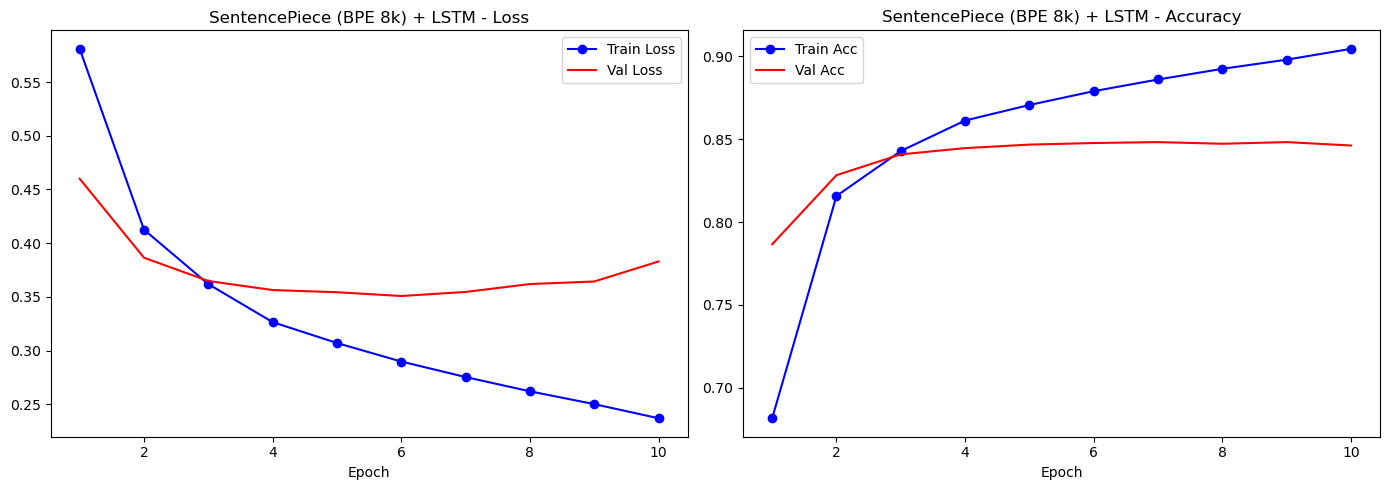


=== SentencePiece (BPE 8k) 모델 테스트 결과 ===
Test Loss: 0.3963, Test Accuracy: 0.8431


In [31]:
plot_history(history_sp_bpe8k, title='SentencePiece (BPE 8k) + LSTM')
print('\n=== SentencePiece (BPE 8k) 모델 테스트 결과 ===')
acc_sp_bpe8k = evaluate_model(model_sp_bpe8k, test_loader_bpe)

4. SentencePiece (Unigram, vocab_size=16000)

In [32]:
# Unigram 모델, vocab_size=16000
spm.SentencePieceTrainer.Train(
    f'--input={nsmc_temp_file} '
    f'--model_prefix=nsmc_spm_unigram_16k '
    f'--vocab_size=16000 '
    f'--model_type=unigram '
    f'--pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1'
)
print('Unigram 16k 모델 학습 완료')

sp_uni16k = spm.SentencePieceProcessor()
sp_uni16k.Load('nsmc_spm_unigram_16k.model')

X_train_u16, y_train_u16, X_test_u16, y_test_u16, wi_u16 = load_data_sp(
    train_data, test_data, sp_uni16k)

all_len_u16 = [len(s) for s in X_train_u16 + X_test_u16]
maxlen_u16 = int(np.mean(all_len_u16) + 2 * np.std(all_len_u16))
print(f'평균 토큰 수: {np.mean(all_len_u16):.1f}, maxlen: {maxlen_u16}')

Unigram 16k 모델 학습 완료


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_train_text.txt --model_prefix=nsmc_spm_unigram_16k --vocab_size=16000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_train_text.txt
  input_format: 
  model_prefix: nsmc_spm_unigram_16k
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_fi

평균 토큰 수: 15.5, maxlen: 41


In [33]:
train_loader_u16, val_loader_u16, test_loader_u16 = build_loaders(
    X_train_u16, y_train_u16, X_test_u16, y_test_u16, maxlen=maxlen_u16, batch_size=batch_size)

model_sp_uni16k = LSTMModel(len(wi_u16), embedding_dim)
print('학습 시작 (SentencePiece Unigram 16k + LSTM)...')
history_sp_uni16k = train_model(model_sp_uni16k, train_loader_u16, val_loader_u16, epochs=10)

학습 시작 (SentencePiece Unigram 16k + LSTM)...
Epoch  1/10 | Train Loss: 0.5927, Acc: 0.6717 | Val Loss: 0.4790, Acc: 0.7740
Epoch  2/10 | Train Loss: 0.4295, Acc: 0.8063 | Val Loss: 0.4060, Acc: 0.8166
Epoch  3/10 | Train Loss: 0.3631, Acc: 0.8423 | Val Loss: 0.3888, Acc: 0.8294
Epoch  4/10 | Train Loss: 0.3226, Acc: 0.8637 | Val Loss: 0.3670, Acc: 0.8411
Epoch  5/10 | Train Loss: 0.2915, Acc: 0.8788 | Val Loss: 0.3650, Acc: 0.8437
Epoch  6/10 | Train Loss: 0.2679, Acc: 0.8901 | Val Loss: 0.3693, Acc: 0.8454
Epoch  7/10 | Train Loss: 0.2477, Acc: 0.8999 | Val Loss: 0.3807, Acc: 0.8466
Epoch  8/10 | Train Loss: 0.2302, Acc: 0.9080 | Val Loss: 0.3787, Acc: 0.8456
Epoch  9/10 | Train Loss: 0.2134, Acc: 0.9164 | Val Loss: 0.4036, Acc: 0.8461
Epoch 10/10 | Train Loss: 0.1981, Acc: 0.9230 | Val Loss: 0.4271, Acc: 0.8433

Early Stopping! Best Val Acc: 0.8466


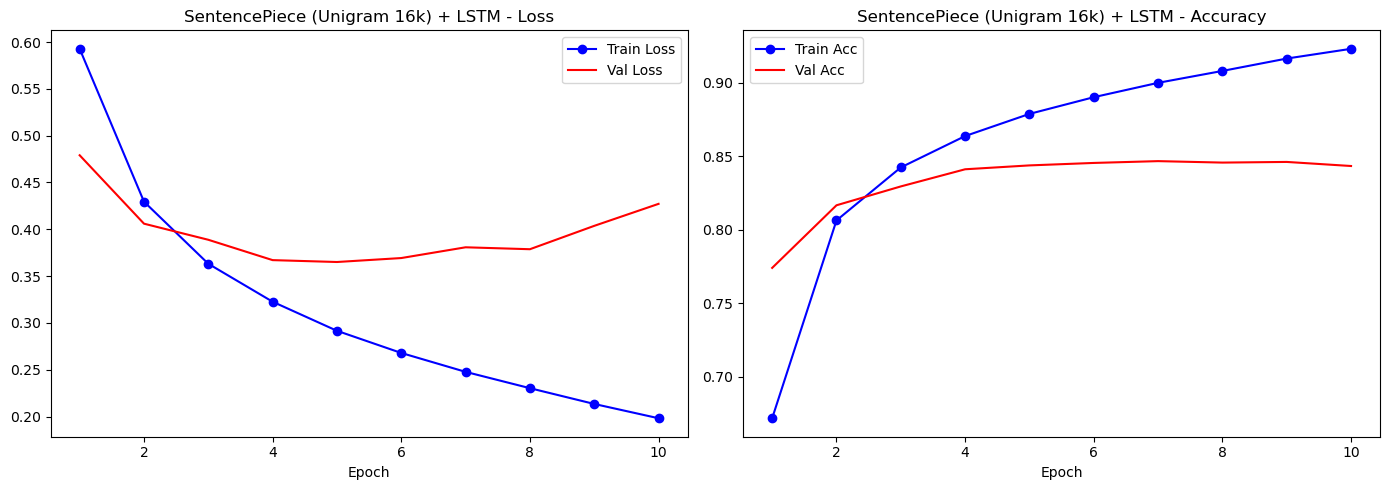


=== SentencePiece (Unigram 16k) 모델 테스트 결과 ===
Test Loss: 0.4433, Test Accuracy: 0.8389


In [34]:
plot_history(history_sp_uni16k, title='SentencePiece (Unigram 16k) + LSTM')
print('\n=== SentencePiece (Unigram 16k) 모델 테스트 결과 ===')
acc_sp_uni16k = evaluate_model(model_sp_uni16k, test_loader_u16)

5. SentencePiece (BPE, vocab_size=16000)

In [36]:
spm.SentencePieceTrainer.Train(
    f'--input={nsmc_temp_file} '
    f'--model_prefix=nsmc_spm_bpe_16k '
    f'--vocab_size=16000 '
    f'--model_type=bpe '
    f'--pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1'
)
print('BPE 16k 모델 학습 완료')

sp_bpe16k = spm.SentencePieceProcessor()
sp_bpe16k.Load('nsmc_spm_bpe_16k.model')

X_train_b16, y_train_b16, X_test_b16, y_test_b16, wi_b16 = load_data_sp(
    train_data, test_data, sp_bpe16k)

all_len_b16 = [len(s) for s in X_train_b16 + X_test_b16]
maxlen_b16 = int(np.mean(all_len_b16) + 2 * np.std(all_len_b16))
print(f'평균 토큰 수: {np.mean(all_len_b16):.1f}, maxlen: {maxlen_b16}')

BPE 16k 모델 학습 완료
평균 토큰 수: 15.1, maxlen: 40


In [37]:
train_loader_b16, val_loader_b16, test_loader_b16 = build_loaders(
    X_train_b16, y_train_b16, X_test_b16, y_test_b16, maxlen=maxlen_b16, batch_size=batch_size)

model_sp_bpe16k = LSTMModel(len(wi_b16), embedding_dim)
print('학습 시작 (SentencePiece BPE 16k + LSTM)...')
history_sp_bpe16k = train_model(model_sp_bpe16k, train_loader_b16, val_loader_b16, epochs=10)

학습 시작 (SentencePiece BPE 16k + LSTM)...
Epoch  1/10 | Train Loss: 0.6061, Acc: 0.6562 | Val Loss: 0.4897, Acc: 0.7650
Epoch  2/10 | Train Loss: 0.4332, Acc: 0.8026 | Val Loss: 0.4095, Acc: 0.8146
Epoch  3/10 | Train Loss: 0.3589, Acc: 0.8451 | Val Loss: 0.3796, Acc: 0.8315
Epoch  4/10 | Train Loss: 0.3155, Acc: 0.8679 | Val Loss: 0.3723, Acc: 0.8383
Epoch  5/10 | Train Loss: 0.2848, Acc: 0.8824 | Val Loss: 0.3689, Acc: 0.8444
Epoch  6/10 | Train Loss: 0.2597, Acc: 0.8946 | Val Loss: 0.3727, Acc: 0.8421
Epoch  7/10 | Train Loss: 0.2382, Acc: 0.9052 | Val Loss: 0.3874, Acc: 0.8434
Epoch  8/10 | Train Loss: 0.2179, Acc: 0.9147 | Val Loss: 0.4009, Acc: 0.8430

Early Stopping! Best Val Acc: 0.8444


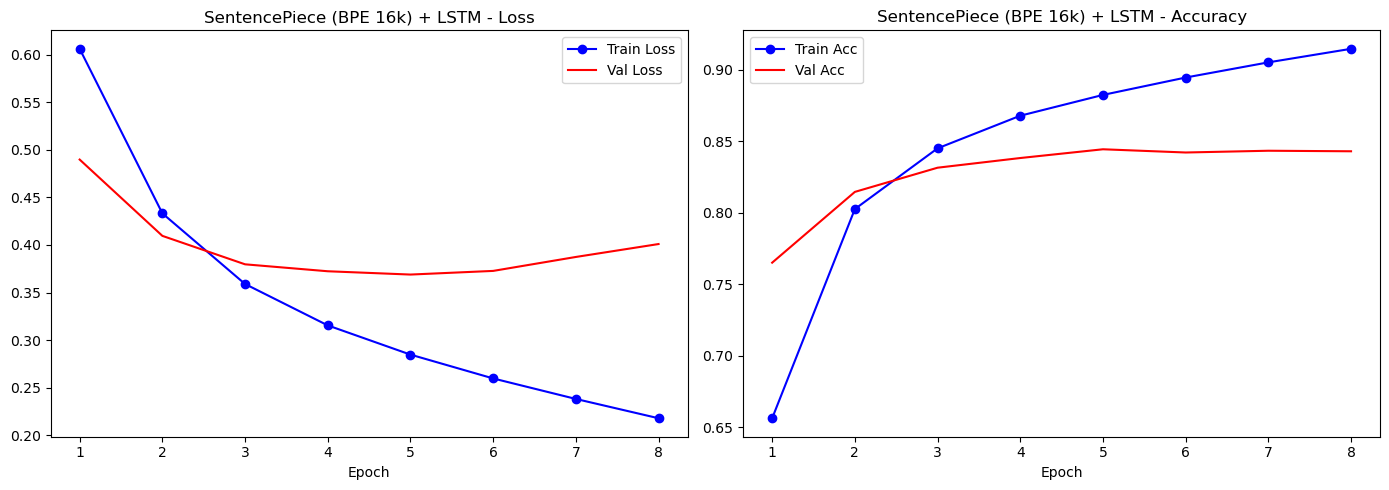


=== SentencePiece (BPE 16k) 모델 테스트 결과 ===
Test Loss: 0.4171, Test Accuracy: 0.8386


In [38]:
plot_history(history_sp_bpe16k, title='SentencePiece (BPE 16k) + LSTM')
print('\n=== SentencePiece (BPE 16k) 모델 테스트 결과 ===')
acc_sp_bpe16k = evaluate_model(model_sp_bpe16k, test_loader_b16)

### 종합 비교 및 분석 결과

In [39]:
# 결과 종합 테이블
results = {
    'Tokenizer': [
        'MeCab (형태소)',
        'SP Unigram 8k',
        'SP BPE 8k',
        'SP Unigram 16k',
        'SP BPE 16k'
    ],
    'Vocab Size': [
        len(word_index_m),
        len(word_index_sp),
        len(wi_bpe),
        len(wi_u16),
        len(wi_b16)
    ],
    'Test Accuracy': [
        acc_mecab,
        acc_sp_uni8k,
        acc_sp_bpe8k,
        acc_sp_uni16k,
        acc_sp_bpe16k
    ]
}

results_df = pd.DataFrame(results)
results_df['Test Accuracy'] = results_df['Test Accuracy'].apply(lambda x: f'{x:.4f}')
print(results_df.to_string(index=False))

     Tokenizer  Vocab Size Test Accuracy
   MeCab (형태소)       10000        0.8483
 SP Unigram 8k        8000        0.8425
     SP BPE 8k        8000        0.8431
SP Unigram 16k       16000        0.8389
    SP BPE 16k       16000        0.8386


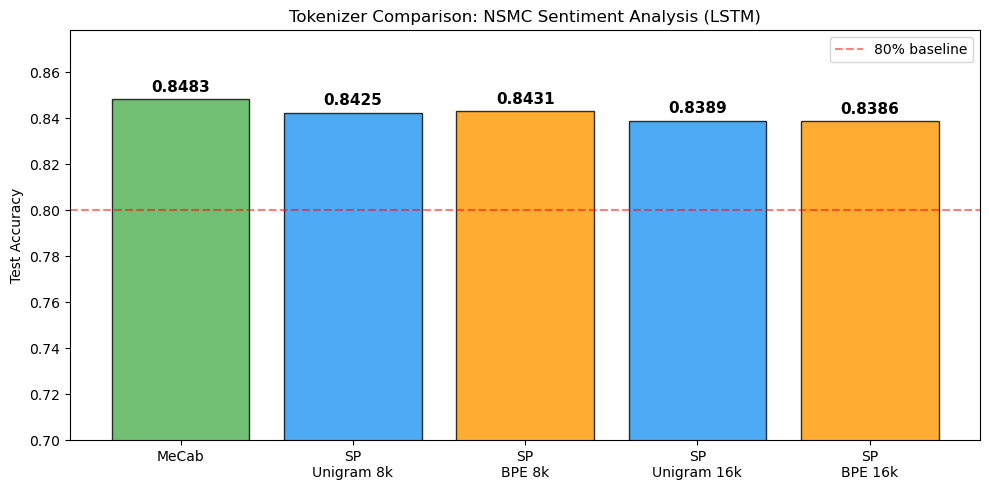

In [40]:
# 시각화: 토크나이저별 Test Accuracy 비교
labels = ['MeCab', 'SP\nUnigram 8k', 'SP\nBPE 8k', 'SP\nUnigram 16k', 'SP\nBPE 16k']
accuracies = [acc_mecab, acc_sp_uni8k, acc_sp_bpe8k, acc_sp_uni16k, acc_sp_bpe16k]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#2196F3', '#FF9800']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='black', alpha=0.8)

# 막대 위에 정확도 표시
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Test Accuracy')
plt.title('Tokenizer Comparison: NSMC Sentiment Analysis (LSTM)')
plt.ylim(0.7, max(accuracies) + 0.03)
plt.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='80% baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# 동일한 문장에 대해 각 토크나이저의 토큰화 결과를 비교
sample_sentences = [
    '이 영화 진짜 재미없어요 시간 아깝다',
    '배우들의 연기력이 정말 대단했습니다 감동적인 영화였어요',
    '스토리가 뻔해서 졸렸음 비추',
    '올해 최고의 영화!! 꼭 보세요ㅎㅎ'
]

for sent in sample_sentences:
    print(f'원문: {sent}')
    print(f'  MeCab     : {mecab.morphs(sent)}')
    print(f'  SP Uni 8k : {sp_nsmc.EncodeAsPieces(sent)}')
    print(f'  SP BPE 8k : {sp_bpe8k.EncodeAsPieces(sent)}')
    print(f'  SP Uni 16k: {sp_uni16k.EncodeAsPieces(sent)}')

원문: 이 영화 진짜 재미없어요 시간 아깝다
  MeCab     : ['이', '영화', '진짜', '재미없', '어요', '시간', '아깝', '다']
  SP Uni 8k : ['▁이', '▁영화', '▁진짜', '▁재미없어요', '▁시간', '▁아깝다']
  SP BPE 8k : ['▁이', '▁영화', '▁진짜', '▁재미없어요', '▁시간', '▁아깝다']
  SP Uni 16k: ['▁이', '▁영화', '▁진짜', '▁재미없어요', '▁시간', '▁아깝다']
원문: 배우들의 연기력이 정말 대단했습니다 감동적인 영화였어요
  MeCab     : ['배우', '들', '의', '연기력', '이', '정말', '대단', '했', '습니다', '감동', '적', '인', '영화', '였', '어요']
  SP Uni 8k : ['▁배우들의', '▁연기력이', '▁정말', '▁대단', '했습니다', '▁감동적인', '▁영화였어요']
  SP BPE 8k : ['▁배우들의', '▁연기력이', '▁정말', '▁대단', '했습니다', '▁감동적인', '▁영화였어요']
  SP Uni 16k: ['▁배우들의', '▁연기력이', '▁정말', '▁대단', '했습니다', '▁감동적인', '▁영화였어요']
원문: 스토리가 뻔해서 졸렸음 비추
  MeCab     : ['스토리', '가', '뻔해서', '졸', '렸', '음', '비추']
  SP Uni 8k : ['▁스토리가', '▁뻔', '해서', '▁졸', '렸', '음', '▁비추']
  SP BPE 8k : ['▁스토리가', '▁뻔', '해서', '▁졸', '렸', '음', '▁비추']
  SP Uni 16k: ['▁스토리가', '▁뻔해서', '▁졸', '렸', '음', '▁비추']
원문: 올해 최고의 영화!! 꼭 보세요ㅎㅎ
  MeCab     : ['올해', '최고', '의', '영화', '!', '!', '꼭', '보', '세요', 'ㅎㅎ']
  SP Uni 8k : ['▁올해', '▁최고의', '▁영화

### 회고

Ex05 프로젝트에서 사용한 모델과 다른 부분
- 기존 코드를 그대로 사용하려다가 과적합 문제가 심했어서
   - 이를 해결하기 위해 LSTM 모델을 단순화하고 임베딩 차원을 64로 축소시키고 Ealry Stopping을 추가했다

분석
- MeCab이 가장 높은 성능을 보임
  - 아마 한국어 특화 분석기라는 장점이 크게 작용한 것으로 생각
  - 토큰화 결과를 봤을 때에도 SentencePiece 와 달리, 형태소 기반으로 잘 처리함
  - 이런 토큰화 결과가 분명 감정 분석이라는 태스크에도 크게 작용했을 것이다
- Unigram과 BPE 알고리즘은 큰 차이는 없었다
  - 토큰화 결과도 동일
- vocab_size 옵션
  - 여기도 엄청나게 큰 차이는 아니지만, 작을수록 성능이 좋았음

배운 점
- sentencepiece는 별도의 전처리없이 바로 활용할 수 있어 편리하고, vocab_size도 미리 설정하는 등 연산량 조정을 할 수 있으며 성능도 뛰어나지만
  - 한국어라는 교착어에 한정해서는 형태소 분석기를 이용하는 것이 더 좋을 수 있다
- 토크나이저와 알고리즘, vocab_size 옵션을 비교하며
  - 토큰 크기, vocab_size, 의미 부여 사이의 tradeoff에 대해 다시 생각해볼 수 있었다
  - 특히, vocab_size를 무작정 키운다고 좋은 것이 아니라 데이터의 규모와 모델의 복잡도를 함께 고려해야 한다는 점